In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Airbnb_datanew.csv')
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05-07-2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19-11-2018,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
48891,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
48892,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
48893,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False


In [6]:
# rename id and name to more specific names

df.rename(columns={'id':'airbnb_id'},inplace=True)
df.rename(columns={'name':'airbnb_name'},inplace=True)

In [7]:
df.isnull().sum()

airbnb_id                             0
airbnb_name                          16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
df = df.drop(columns = ['last_review'])
df

,airbnb_id,airbnb_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


In [9]:
df.isnull().sum()

airbnb_id                             0
airbnb_name                          16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
df['airbnb_name'] = df['airbnb_name'].fillna("")
df['host_name'] = df['host_name'].fillna("Not Available")

In [11]:
df.isnull().sum()

airbnb_id                             0
airbnb_name                           0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [12]:
df.sample(15)

,airbnb_id,airbnb_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
41019,31894855,Best Upper West Side Two Bedroom Apartment,320428,David,Manhattan,Upper West Side,40.79095,-73.97291,Entire home/apt,142,7,5,1.17,1,214
25078,20085006,Bright & Beautiful Brooklyn Boudoir and more! ☺,142590597,Joica,Brooklyn,East New York,40.67296,-73.87435,Entire home/apt,249,1,7,0.38,6,177
30261,23373453,"""Grandma Chic"" Brooklyn Apartment... Williamsburg",23089194,Katie,Brooklyn,Williamsburg,40.71536,-73.94058,Private room,69,5,6,0.51,1,0
11625,9046095,Private & Quaint West Village Gem!,12995701,Robyn,Manhattan,West Village,40.73208,-74.00393,Entire home/apt,200,4,1,0.02,1,0
27609,21713358,Modern Whimsical Room,63749946,Rachel,Brooklyn,Crown Heights,40.67433,-73.92480,Private room,54,4,11,0.56,3,0
35631,28288433,Beatuful Harlem Urban Penthouse,213635139,Elvis,Manhattan,East Harlem,40.79824,-73.94014,Entire home/apt,300,2,53,5.96,1,14
33265,26270554,Spacious & primely-located Brooklyn apartment,28186801,Kate,Brooklyn,Williamsburg,40.71882,-73.94943,Entire home/apt,260,2,1,0.08,1,0
14669,11588003,Charming Prewar Upper West Side Apt,4732500,Daniel,Manhattan,Upper West Side,40.79828,-73.97166,Entire home/apt,95,1,0,NaN,1,0
4597,3215486,Large sunny private room downtown,7691955,Ingrid,Manhattan,Lower East Side,40.71981,-73.98701,Private room,81,3,9,0.19,1,0
21102,16736830,Modern & classic 3-BR apt in private brownstone,4547658,Christine,Brooklyn,Park Slope,40.67451,-73.97501,Entire home/apt,275,2,119,4.08,1,65


In [13]:
df.describe()

,airbnb_id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [14]:
#Q1. How many unique neighbourhoods we are having ?
df['neighbourhood'].nunique()

221

In [15]:
#Q2. How many unique neighbourhood groups we are having ?
df['neighbourhood_group'].nunique()

5

In [16]:
#Q3. How many unique hosts we are having ?
df['host_id'].nunique()

37457

In [17]:
#Q4. How many unique properties we are having ?
df['airbnb_id'].nunique()

48895

In [18]:
#Q5. How many unique airbnb names we are having ?
df['airbnb_name'].nunique()

47897

In [19]:
#Q5. Which type of room is mostly present in the given airbnbs ?
df['room_type'].mode()

0    Entire home/apt
Name: room_type, dtype: object

In [20]:
# Lets do the analysis of price column:

# mean
print(df['price'].mean())
# median
print(df['price'].median())
# mode
print(df['price'].mode())
# skew
print(df['price'].skew())
# std
print(df['price'].std())


152.7206871868289
106.0
0    100
Name: price, dtype: int64
19.118938995046033
240.15416974718727


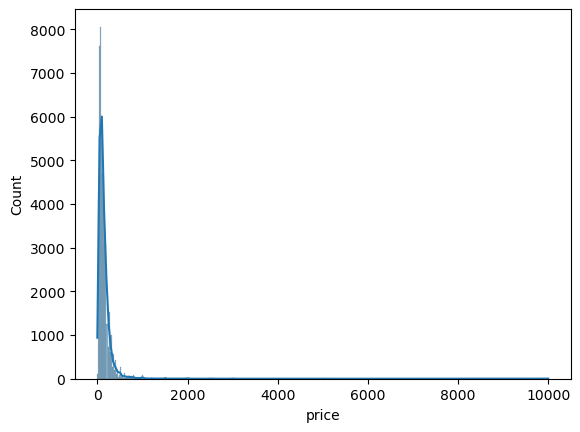

In [21]:
sns.histplot(df['price'], kde = True)
plt.show()

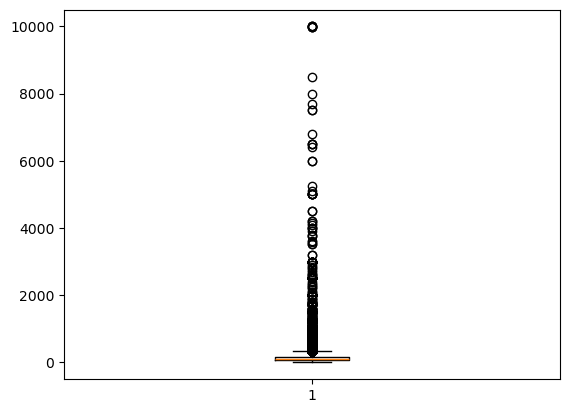

In [22]:
#check outliers - boxplot, remove them - IQR
plt.boxplot(df['price'])
plt.show()

In [23]:
#IQR
q1 = np.percentile(df['price'],25)
q3 = np.percentile(df['price'],75)
iqr = q3 - q1

#upper limit
ul = q3 + 1.5*iqr
#lower limit
ll = q1-1.5*iqr

In [24]:
df = df[(df['price'] < ul) & (df['price'] > ll)]

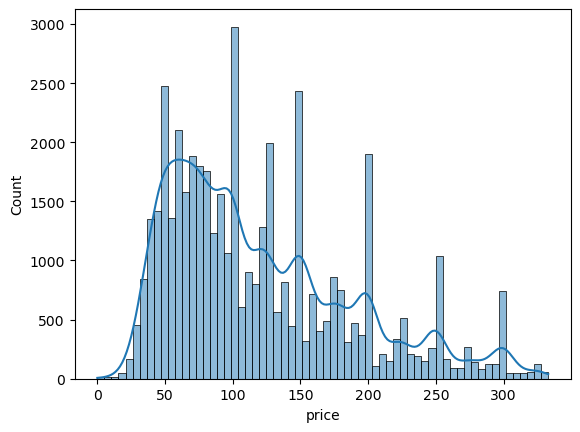

In [25]:
sns.histplot(df['price'], kde = True)
plt.show()

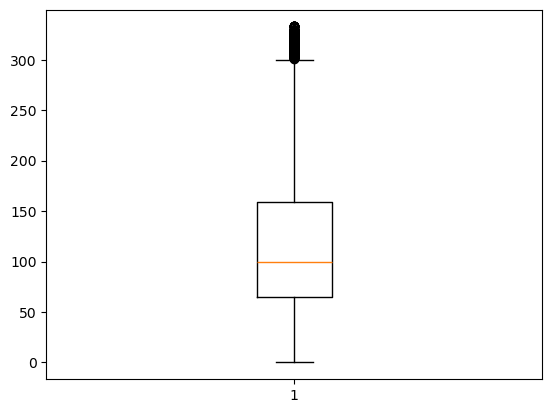

In [26]:
plt.boxplot(df['price'])
plt.show()

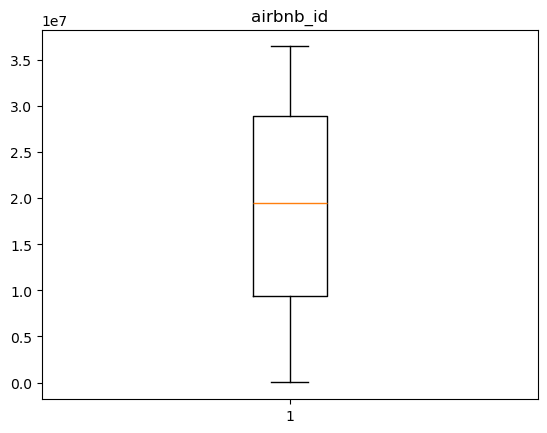

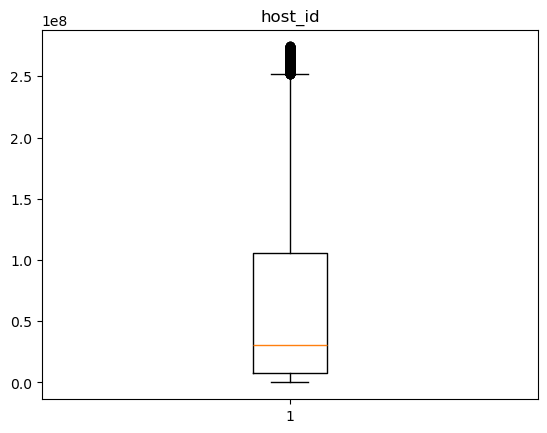

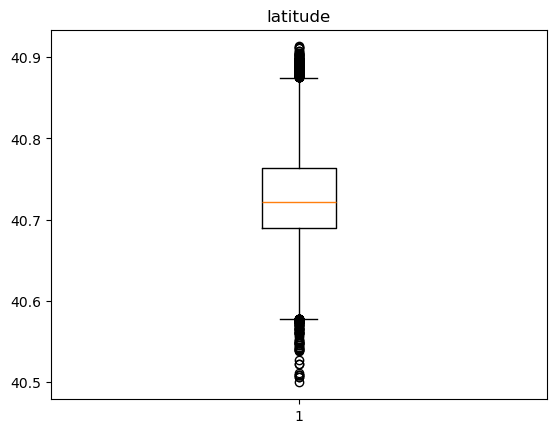

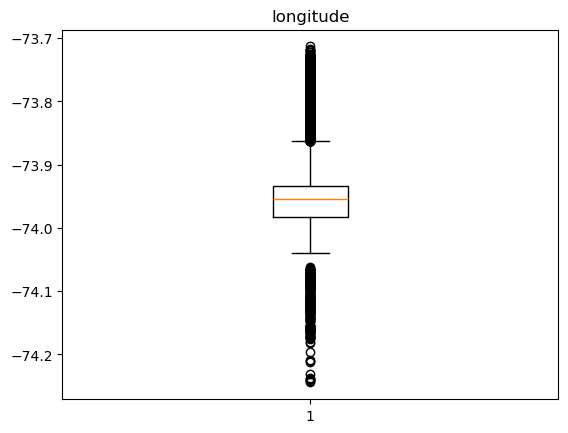

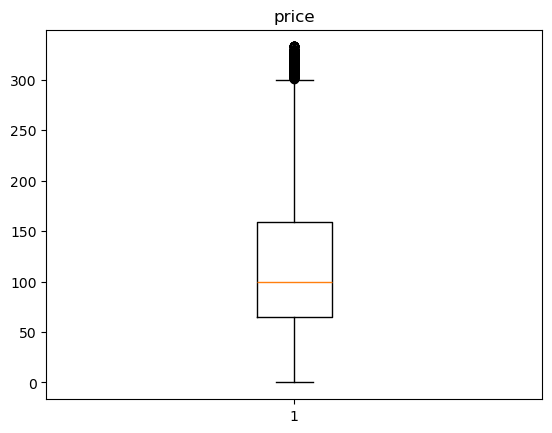

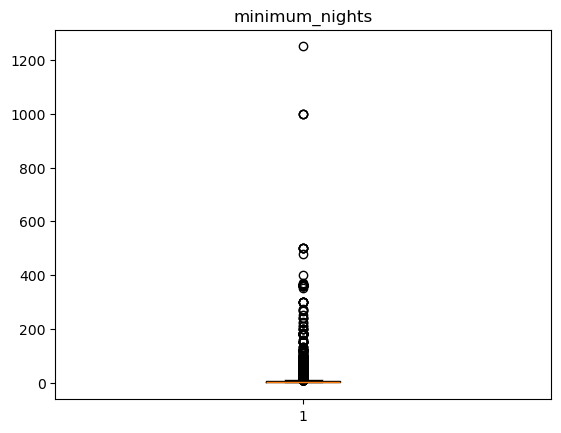

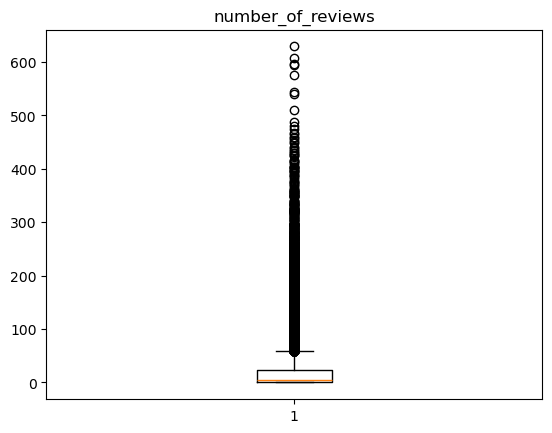

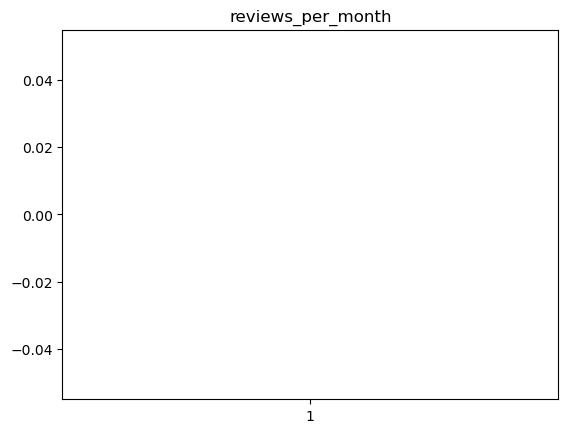

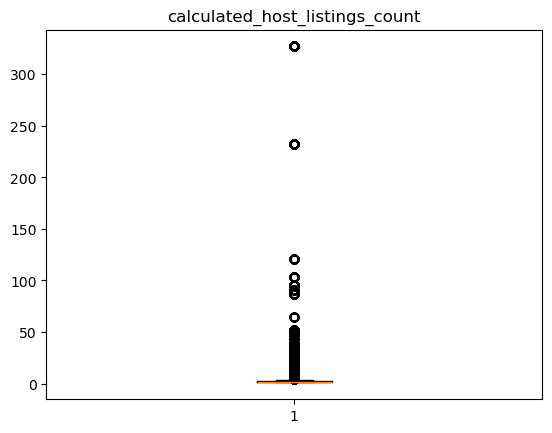

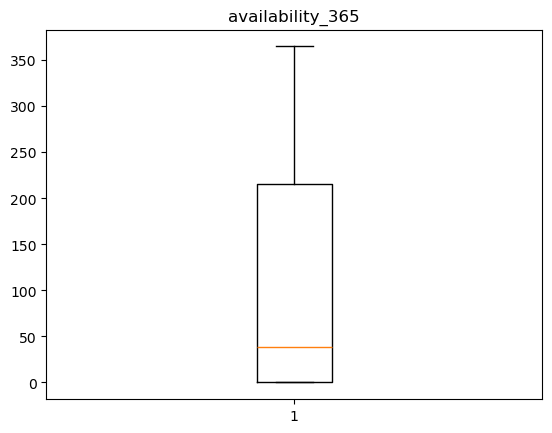

In [27]:
for col in df.columns:
    if df[col].dtypes !=  'object':
        plt.boxplot(df[col])
        plt.title(col)
        plt.show()

In [28]:
# for col in df.columns:
#     if df[col].dtypes !=  'object':
#         q1 = np.percentile(df[col],25)
#         q3 = np.percentile(df[col],75)
#         iqr = q3-q1
#         ul = q3 + 1.5*iqr
#         ll = q1 - 1.5*iqr
#         df = df[(df[col] < ul) & (df[col] > ll)]
#         plt.boxplot(df[col])
#         plt.title(col)
#         plt.show()

In [29]:
#Average price by neighbourhood group
df.groupby('neighbourhood_group')['price'].mean()

neighbourhood_group
Bronx             77.365421
Brooklyn         105.699614
Manhattan        145.904620
Queens            88.904437
Staten Island     89.235616
Name: price, dtype: float64

In [30]:
df.groupby('room_type')['price'].mean().head(1)

room_type
Entire home/apt    162.489466
Name: price, dtype: float64

In [35]:
df['neighbourhood_group'].value_counts().sort_values(ascending = False)

neighbourhood_group
Manhattan        19501
Brooklyn         19415
Queens            5567
Bronx             1070
Staten Island      365
Name: count, dtype: int64

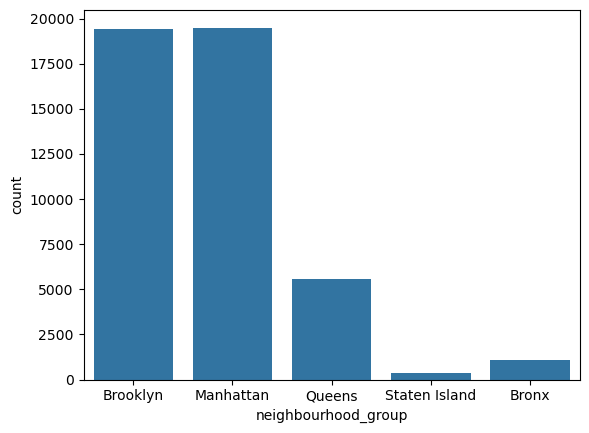

In [33]:
sns.countplot(data = df, x = 'neighbourhood_group')
plt.show()